<style>
    /* 標題允許 lower case */
    .reveal h1, .reveal h2, .reveal h3 {
        text-transform: none !important;
    }
    /* 針對 Voila 渲染後的輸出區域進行置中 */
    .output_subarea, .jp-OutputArea-output {
        text-align: center;
        display: flex;
        flex-direction: column;
        align-items: center;
    }
    
    /* 確保圖片本身不會超出容器 */
    .output_png img {
        display: block;
        margin-left: auto;
        margin-right: auto;
    }

    /* 防止 Markdown 輸出產生滾動條 */
    .jp-MarkdownOutput {
        overflow: visible !important;
    }
</style>

# Rates Volatility Modeling


# Option Pricing Basics

* **The Fundamental Principle:** In a no-arbitrage market, the price of any derivative with payoff $X$ is the expectation of its discounted payoff under a risk-neutral measure $P^M$
* **The Universal Formula:** 
    * $M_t$: Time-$t$ value of the money market account with $M_0 = 1$ (the Numeraire)
    * $P^M$: The risk-neutral probability measure associated with $M$
$$
V_0 = M_0 E^M \left[ M_T^{-1} X_T \right]
$$


# Binomial Option Pricing Model (BOPM) 

* We want to price an option on a stock trading at $S$ currently
* Assumptions:
    * Only two discrete times (one time step): Today at $t=0$ and maturity at $t=1$
    * At $t=1$, the stock price can either go up to $S_u$ or go down to $S_d$ (two states), with corresponding option prices $C_u$ and $C_d$, respectively
    * A money market account **(MMA) with initial value 1 will become $M$ at $t=1$**

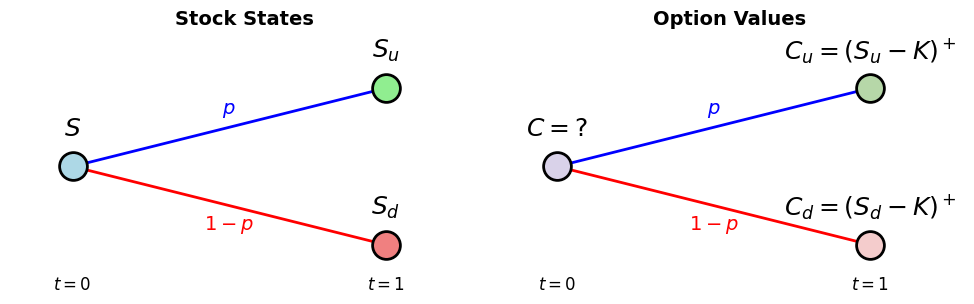

In [1]:
# Single-step binomial tree visualization (stock + option payoff tree)
import matplotlib.pyplot as plt

fig, (ax_stock, ax_opt) = plt.subplots(1, 2, figsize=(10, 3.5))

# Shared node positions
t0_x, t0_y = 0, 0.5
t1_u_x, t1_u_y = 1, 0.75
t1_d_x, t1_d_y = 1, 0.25
node_size = 400

# -------- Left panel: stock tree --------
ax_stock.plot([t0_x, t1_u_x], [t0_y, t1_u_y], 'b-', lw=2, label='Up move')
ax_stock.plot([t0_x, t1_d_x], [t0_y, t1_d_y], 'r-', lw=2, label='Down move')
ax_stock.scatter([t0_x], [t0_y], s=node_size, c='lightblue', edgecolors='black', zorder=5, linewidths=2)
ax_stock.scatter([t1_u_x], [t1_u_y], s=node_size, c='lightgreen', edgecolors='black', zorder=5, linewidths=2)
ax_stock.scatter([t1_d_x], [t1_d_y], s=node_size, c='lightcoral', edgecolors='black', zorder=5, linewidths=2)
ax_stock.text(t0_x, t0_y + 0.12, r'$S$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(t1_u_x, t1_u_y + 0.12, r'$S_u$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(t1_d_x, t1_d_y + 0.12, r'$S_d$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(0.5, 0.65, r'$p$', fontsize=14, ha='center', va='bottom', color='blue')
ax_stock.text(0.5, 0.35, r'$1-p$', fontsize=14, ha='center', va='top', color='red')
ax_stock.text(t0_x, 0.15, r'$t=0$', fontsize=12, ha='center', va='top')
ax_stock.text(t1_u_x, 0.15, r'$t=1$', fontsize=12, ha='center', va='top')
ax_stock.set_xlim(-0.2, 1.3)
ax_stock.set_ylim(0.2, 0.9)
ax_stock.set_aspect('equal')
ax_stock.axis('off')
ax_stock.set_title('Stock States', fontsize=14, fontweight='bold', pad=12)

# -------- Right panel: option value tree --------
ax_opt.plot([t0_x, t1_u_x], [t0_y, t1_u_y], 'b-', lw=2)
ax_opt.plot([t0_x, t1_d_x], [t0_y, t1_d_y], 'r-', lw=2)
ax_opt.scatter([t0_x], [t0_y], s=node_size, c='#d9d2e9', edgecolors='black', zorder=5, linewidths=2)
ax_opt.scatter([t1_u_x], [t1_u_y], s=node_size, c='#b6d7a8', edgecolors='black', zorder=5, linewidths=2)
ax_opt.scatter([t1_d_x], [t1_d_y], s=node_size, c='#f4cccc', edgecolors='black', zorder=5, linewidths=2)
ax_opt.text(t0_x, t0_y + 0.12, r'$C=?$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(t1_u_x, t1_u_y + 0.12, r'$C_u = (S_u - K)^+$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(t1_d_x, t1_d_y + 0.12, r'$C_d = (S_d - K)^+$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(0.5, 0.65, r'$p$', fontsize=14, ha='center', va='bottom', color='blue')
ax_opt.text(0.5, 0.35, r'$1-p$', fontsize=14, ha='center', va='top', color='red')
ax_opt.text(t0_x, 0.15, r'$t=0$', fontsize=12, ha='center', va='top')
ax_opt.text(t1_u_x, 0.15, r'$t=1$', fontsize=12, ha='center', va='top')
ax_opt.set_xlim(-0.2, 1.3)
ax_opt.set_ylim(0.2, 0.9)
ax_opt.set_aspect('equal')
ax_opt.axis('off')
ax_opt.set_title('Option Values', fontsize=14, fontweight='bold', pad=12)

# fig.suptitle('One-Step Binomial Trees', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# BOPM No-Arbitrage Argument

* **Replication Argument:** 
    * Set up a portfolio so that its value at $t=1$ replicates the option in both states
    * By no-arbitrage, the option price and the portfolio value at $t=0$ should equal


* The portfolio setup at $t=0$:
    * Buy $\Delta {\color{lightgray}~= (C_u - C_d)/(S_u - S_d)}$ shares of the stock at $S$
    * Deposit $B {\color{lightgray}~= (C_dS_u - C_uS_d)/(M(S_u - S_d))}$ dollars into MMA
* It can be easily verified that the portfolio value and option price agree at $t=1$ in both states:
\begin{align*}
\Delta S_u + BM &= C_u\\
\Delta S_d + BM &= C_d
\end{align*}


* Initial portfolio value is $\Delta S+B$:
$$
C = \underbrace{\color{lightgray}\left(\frac{SM - S_d}{S_u - S_d}\right)}_{p^M} \frac{C_u}{M} + \underbrace{\color{lightgray}\left(\frac{S_u - SM}{S_u - S_d}\right)}_{1-p^M} \frac{C_d}{M} = M_0E^M[M^{-1}_T X]
$$

<div class="fragment">
    <ul style="text-align: left; margin-bottom: 0;">
        <li>Initial portfolio value is $\Delta S+B$: </li>
    </ul>
    <div style="text-align: center; width: 100%;">
        $$C = \underbrace{\color{lightgray}\left(\frac{SM - S_d}{S_u - S_d}\right)}_{p^M} \frac{C_u}{M} + \underbrace{\color{lightgray}\left(\frac{S_u - SM}{S_u - S_d}\right)}_{1-p^M} \frac{C_d}{M} = M_0E^M[M^{-1}_T X]$$
    </div>
</div>

# Risk-Neutral Probability in BOPM

* $p^M \ne p$ the physical probability which is not in the story
* Even if an agent is confident about $p$, he/she should still quote the option at the fair price $M_0E^M[M_T^{-1} X]$, as that's **the price to guarantee no arbitrage**


# Delta Hedge in BOPM

* Replicating Portfolio
    * $\Delta = (C_u - C_d)/(S_u - S_d)$ shares of the stock at $S$
    * Some MMA (risk free)

\begin{align*}
\text{Option} &= \text{Replicating Portfolio}\\
&= \Delta\text{ Shares of Stock} + \text{MMA}
\end{align*}

$$
\text{Option} - \Delta\text{ Shares of Stock} = \text{MMA}
$$

# Multi-Step BOPM

* **Pricing:** Construct replicating portfolios at each one-step sub-tree, computing expectations under the risk-neutral probability backward in time from maturity $T$
* **Dynamic Hedging:** Compute $\Delta$ at each node and dynamically rebalance to ensure a locally risk-free portfolio across every time step

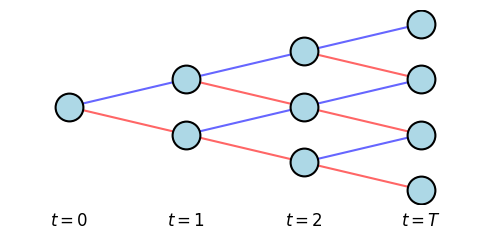

In [2]:
# 3-step recombining binomial tree visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.5))

steps = 3
node_size = 400

# Draw recombining tree nodes and edges
for i in range(steps):
    for j in range(i + 1):
        # Current node (t=i)
        curr_x = i
        curr_y = j * 2 - i
        
        # Up move (t=i+1)
        up_x = i + 1
        up_y = (j + 1) * 2 - (i + 1)
        ax.plot([curr_x, up_x], [curr_y, up_y], 'b-', lw=1.5, alpha=0.6)
        
        # Down move (t=i+1)
        down_x = i + 1
        down_y = j * 2 - (i + 1)
        ax.plot([curr_x, down_x], [curr_y, down_y], 'r-', lw=1.5, alpha=0.6)

# Scatter plot for nodes to overlay on top of lines
for i in range(steps + 1):
    for j in range(i + 1):
        x = i
        y = j * 2 - i
        ax.scatter(x, y, s=node_size, c='lightblue', edgecolors='black', zorder=5, linewidths=1.5)
        # Label each node generically, or using S_... string
        # Number of up moves = j, number of down moves = i - j
        # ax.text(x, y, f'{j}U\n{i-j}D', fontsize=9, ha='center', va='center', fontweight='bold', zorder=10)

ax.set_xticks(range(steps + 1))
ax.set_xticklabels([f't={i}' for i in range(steps + 1)])
ax.set_yticks([])
ax.set_xlim(-0.5, steps + 0.5)
ax.set_ylim(-steps - 0.5, steps + 0.5)
ax.axis('off')

# Explicitly add time labels at the bottom since axis is off
for i in range(steps):
    ax.text(i, -steps - 0.8, f'$t=${i}', fontsize=12, ha='center', va='top')

ax.text(steps, -steps - 0.8, f'$t=T$', fontsize=12, ha='center', va='top')

# ax.set_title('3-Step Recombining Binomial Tree', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

* With infinitely many time steps, the tree describes a continuous-time stochastic process, and with right assumptions the option price converges to the Black-Scholes formula

# Vanilla Option Pricing Models

* **All we need is a terminal distribution** at the expiry $T$ if our goal is to price/hedge one single vanilla option
* **Black Normal Model:** The underlying (say, a forward rate) follows a scaled Brownian motion
$$
dF_t = \sigma\,dW_t \quad\implies\quad F_T\sim N(0, \sigma^2 T), 
$$
which leads to nice closed form formulas
* **The Reality:** Rates are not normally distributed. The market implied distribution has nonzero skewness and excess kurtosis
    * We need models, like SABR, that parameterize the first 4 moments of the distribution

* Implied Volatility: Equating the Black normal formula and the market/model price and back out $\sigma$

# SABR

* $\alpha$ controls overall **level** of the implied vol (2nd moment of the distribution)
* $\rho$ controls the implied vol **skew** (skewness of the distribution, the 3nd moment)
* $\nu$ (vol of vol) controls the implied vol **convexity** (kurtosis, the 4th moment)
\begin{align*}
\begin{cases}
dF_t = \alpha_tF_t^{\beta}\,dW_t\\
d\alpha_t = {\color{red}\nu} \alpha_t\,dZ_t, \qquad {\color{red}\alpha_0 = \alpha}\\
dW_tdZ_t = {\color{red}\rho} dt
\end{cases}
\end{align*}


# SABR (Cont.)

* $\alpha$ controls overall **level** of the implied vol (2nd moment of the distribution)
* $\rho$ controls the implied vol **skew** (skewness of the distribution, the 3nd moment)
* $\nu$ (vol of vol) controls the implied vol **convexity** (kurtosis, the 4th moment)



In [3]:
import numpy as np

def _f_minus_k_ratio(f, k, beta):
    """Hagan's 2002 f minus k ratio - formula (B.67a)."""
    eps = 1e-07  # Numerical tolerance for f-k and beta
    if abs(f-k) > eps:
        if abs(1-beta) > eps:
            return (1 - beta) * (f - k) / (f**(1-beta) - k**(1-beta))
        else:
            return (f - k) / np.log(f / k)
    else:
        return k**beta


def _zeta_over_x_of_zeta(k, f, t, alpha, beta, rho, volvol):
    """Hagan's 2002 zeta / x(zeta) function - formulas (B.67a)-(B.67b)."""
    eps = 1e-07  # Numerical tolerance for zeta
    f_av = np.sqrt(f * k)
    zeta = volvol * (f - k) / (alpha * f_av**beta)
    if abs(zeta) > eps:
        return zeta / _x(rho, zeta)
    else:
        # The ratio converges to 1 when zeta approaches 0
        return 1.


def _x(rho, z):
    """Hagan's 2002 x function - formula (B.67b)."""
    a = (1 - 2*rho*z + z**2)**.5 + z - rho
    b = 1 - rho
    return np.log(a / b)


def normal_vol(k, f, t, alpha, beta, rho, volvol):
    """Hagan's 2002 SABR normal vol expansion - formula (B.67a)."""
    # We break down the complex formula into simpler sub-components
    f_av = np.sqrt(f * k)
    A = - beta * (2 - beta) * alpha**2 / (24 * f_av**(2 - 2 * beta))
    B = rho * alpha * volvol * beta / (4 * f_av**(1 - beta))
    C = (2 - 3 * rho**2) * volvol**2 / 24
    FMKR = _f_minus_k_ratio(f, k, beta)
    ZXZ = _zeta_over_x_of_zeta(k, f, t, alpha, beta, rho, volvol)
    # Aggregate all components into actual formula (B.67a)
    v_n = alpha * FMKR * ZXZ * (1 + (A + B + C) * t)
    return v_n

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pandas import DataFrame
from ipywidgets import interact

import warnings
warnings.filterwarnings('ignore')

@interact(alpha=(0.001, 0.01, 0.001), rho=(-0.99, 0.99, 0.1), volvol=(0.01, 1, 0.1))
def plot(alpha=0.01, rho=0., volvol=0.6):
    beta = 0.6
    F = 0.1
    T = 1
    a = 0.08
    b = 0.12

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    def call(K, F, T, A=1):
        iv = normal_vol(K, F, T, alpha, beta, rho, volvol)
        d = (F-K)/(iv*np.sqrt(T))
        return A*iv*np.sqrt(T)*(norm.pdf(d) + d*norm.cdf(d))

    def put(K, F, T, A=1):
        return call(K, F, T, A) + A*(K-F)

    DataFrame([(K, normal_vol(K, F, T, alpha, beta, rho, volvol)) for K in np.arange(a, b, 0.001)], columns=['K', 'Implied Vol']).set_index('K').plot(style='-.', legend=None, ax=ax1)
    ax1.set(ylim=(-0.001, 0.015), title='SABR Normal Implied Vol')

    DataFrame([(K, call(K, F, T) if K>F else put(K, F, T)) for K in np.arange(a, b, 0.001)], columns=['K', 'OTM Options']).set_index('K').plot(style='-.', legend=None, ax=ax2)
    ax2.set(ylim=(-0.0001, 0.0012), title='OTM Option PV')
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='alpha', max=0.01, min=0.001, step=0.001), FloatSlid…

# SABR $\rho$: The Intuition

* Why does $\rho$, the rates vol correlation, control the IV skew? 
    * Consider an OTM call and put with the same absolute moneyness. They are only trading positive because of the risk they might become ITM as the underlying moves
    * When $\rho \gg 0$ (and vice versa for $\rho \ll 0$)
        * Upside Move: Call becomes ITM, the vol increases
        * Downside Move: Put becomes ITM, the vol increases
        * As option value increases as vol, the call is trading higher than the put

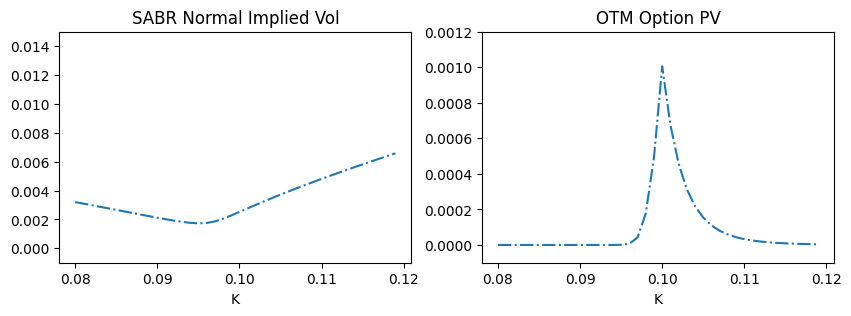

In [5]:
def plot_static(alpha=0.01, rho=0., volvol=0.6, figusize=(10, 3)):
    beta = 0.6
    F = 0.1
    T = 1
    a = 0.08
    b = 0.12

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figusize)
    def call(K, F, T, A=1):
        iv = normal_vol(K, F, T, alpha, beta, rho, volvol)
        d = (F-K)/(iv*np.sqrt(T))
        return A*iv*np.sqrt(T)*(norm.pdf(d) + d*norm.cdf(d))

    def put(K, F, T, A=1):
        return call(K, F, T, A) + A*(K-F)

    DataFrame([(K, normal_vol(K, F, T, alpha, beta, rho, volvol)) for K in np.arange(a, b, 0.001)], columns=['K', 'Implied Vol']).set_index('K').plot(style='-.', legend=None, ax=ax1)
    ax1.set(ylim=(-0.001, 0.015), title='SABR Normal Implied Vol')

    DataFrame([(K, call(K, F, T) if K>F else put(K, F, T)) for K in np.arange(a, b, 0.001)], columns=['K', 'OTM Options']).set_index('K').plot(style='-.', legend=None, ax=ax2)
    ax2.set(ylim=(-0.0001, 0.0012), title='OTM Option PV')
    plt.show()

plot_static(rho=0.8)

# SABR $\nu$: The Intuition

* The Asymmetric Impact of $\nu$ (vol of vol) Shocks
    * Deep OTM (20% OTM): Requires a vol spike to expire ITM; highly dependent on $\nu$
    * Near-the-Money (1% OTM): Insensitive to $\nu$; outcome depends on today's $\alpha$
* Results
    * As $\nu$ goes up, distant tails become more expensive relative to the center
    * $\nu$ as the "tail driver", controls the probability of extreme volatility regimes

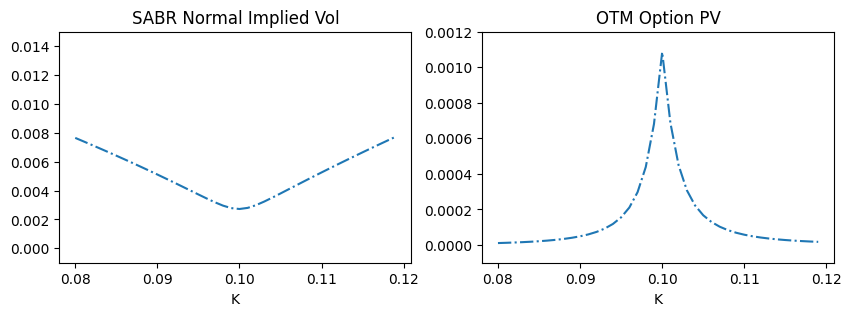

In [6]:
plot_static(volvol=1, figusize=(10, 3))

# Displaced Lognormal Model

* An alternative way to parameterize the first 4 moments
* Volatility is a linear function of the underlying
$$
dF_t = (a_0 + {\color{red}a_1} F_t)\,dW_t
$$
* **${\color{red}a_1}$ controls the IV skew**, same as SABR's $\rho$: 
    * When $a_1 > 0$, the vol goes up as the underlying, same as the $\rho \gg 0$ case (and vice versa for $a_1 < 0$)

* Approximation of the general local volatility model $dF_t = \sigma(F_t)\,dW_t$ as you can expand $\sigma(\cdot)$
* Has closed form formulas for NPV and Greeks
* Allows negative rates which lognormal does not 

* Extension to SV gives us a **vol of vol parameter ${\color{dodgerblue}\nu}$ to control the convexity of IV**, while still preserving semi-closed form formulas
$$
\begin{align*}
\begin{cases}
\color{lightgray}dF_t = {\color{black}\alpha_t}(a_0 + a_1F_t)\,dW_t\\
d\alpha_t = k(\theta - \alpha_t)\,dt + {\color{dodgerblue}\nu}\sqrt{\alpha_t}\,dZ_t
\end{cases}
\end{align*}
$$

# A Better Parametrization

* The displaced lognormal model can be parameterized as
$$
dF_t = \sigma( b F_t + (1-b) F_0)\,dW_t
$$

* **Why This Is Better:**
    * For small $t$ and vol, $b F_t + (1-b) F_0 \approx F_0$ so $\sigma$ has the same scale for all values of $b$
* **Parameter Decoupling:**
    * When $\sigma$ changes, only the IV level changes, not the skew
    * When $b$ changes, only the IV skew change, not the level

* Extension to SV: 
    * $\sigma$ can be made a stochastic volatility process, giving us a vol of vol parameter to control the convexity of IV, while still preserving semi-closed form formulas

# Change of Numeraire

* **Numeraire:** A benchmark asset used as the denominator to price all other assets
* **Change of Numeraire Formula:**
    * $N_t$: Time-$t$ value of the Numeraire
    * $P^N$: The probability measure associated with $N$
$$
V_0 = M_0 E^M \left[ M_T^{-1} X_T \right] = N_0 E^N \left[ N_T^{-1} X_T \right]
$$

# BOPM With Numeraire Asset

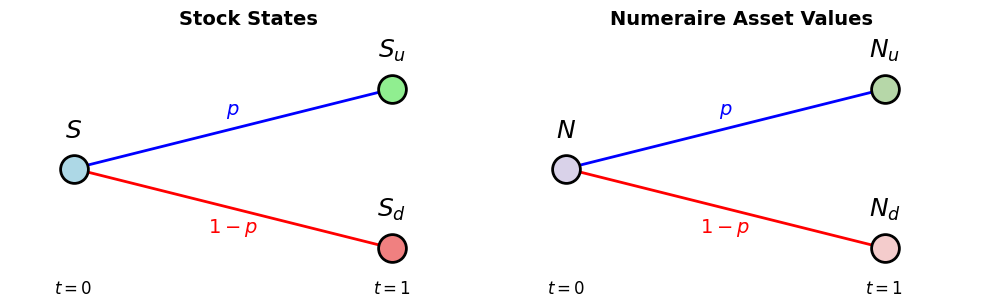

In [7]:
# Single-step binomial tree visualization (stock + option payoff tree)
import matplotlib.pyplot as plt

fig, (ax_stock, ax_opt) = plt.subplots(1, 2, figsize=(10, 3.5))

# Shared node positions
t0_x, t0_y = 0, 0.5
t1_u_x, t1_u_y = 1, 0.75
t1_d_x, t1_d_y = 1, 0.25
node_size = 400

# -------- Left panel: stock tree --------
ax_stock.plot([t0_x, t1_u_x], [t0_y, t1_u_y], 'b-', lw=2, label='Up move')
ax_stock.plot([t0_x, t1_d_x], [t0_y, t1_d_y], 'r-', lw=2, label='Down move')
ax_stock.scatter([t0_x], [t0_y], s=node_size, c='lightblue', edgecolors='black', zorder=5, linewidths=2)
ax_stock.scatter([t1_u_x], [t1_u_y], s=node_size, c='lightgreen', edgecolors='black', zorder=5, linewidths=2)
ax_stock.scatter([t1_d_x], [t1_d_y], s=node_size, c='lightcoral', edgecolors='black', zorder=5, linewidths=2)
ax_stock.text(t0_x, t0_y + 0.12, r'$S$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(t1_u_x, t1_u_y + 0.12, r'$S_u$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(t1_d_x, t1_d_y + 0.12, r'$S_d$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_stock.text(0.5, 0.65, r'$p$', fontsize=14, ha='center', va='bottom', color='blue')
ax_stock.text(0.5, 0.35, r'$1-p$', fontsize=14, ha='center', va='top', color='red')
ax_stock.text(t0_x, 0.15, r'$t=0$', fontsize=12, ha='center', va='top')
ax_stock.text(t1_u_x, 0.15, r'$t=1$', fontsize=12, ha='center', va='top')
ax_stock.set_xlim(-0.2, 1.3)
ax_stock.set_ylim(0.2, 0.9)
ax_stock.set_aspect('equal')
ax_stock.axis('off')
ax_stock.set_title('Stock States', fontsize=14, fontweight='bold', pad=12)

# -------- Right panel: option value tree --------
ax_opt.plot([t0_x, t1_u_x], [t0_y, t1_u_y], 'b-', lw=2)
ax_opt.plot([t0_x, t1_d_x], [t0_y, t1_d_y], 'r-', lw=2)
ax_opt.scatter([t0_x], [t0_y], s=node_size, c='#d9d2e9', edgecolors='black', zorder=5, linewidths=2)
ax_opt.scatter([t1_u_x], [t1_u_y], s=node_size, c='#b6d7a8', edgecolors='black', zorder=5, linewidths=2)
ax_opt.scatter([t1_d_x], [t1_d_y], s=node_size, c='#f4cccc', edgecolors='black', zorder=5, linewidths=2)
ax_opt.text(t0_x, t0_y + 0.12, r'$N$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(t1_u_x, t1_u_y + 0.12, r'$N_u$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(t1_d_x, t1_d_y + 0.12, r'$N_d$', fontsize=18, ha='center', va='center', fontweight='bold')
ax_opt.text(0.5, 0.65, r'$p$', fontsize=14, ha='center', va='bottom', color='blue')
ax_opt.text(0.5, 0.35, r'$1-p$', fontsize=14, ha='center', va='top', color='red')
ax_opt.text(t0_x, 0.15, r'$t=0$', fontsize=12, ha='center', va='top')
ax_opt.text(t1_u_x, 0.15, r'$t=1$', fontsize=12, ha='center', va='top')
ax_opt.set_xlim(-0.2, 1.3)
ax_opt.set_ylim(0.2, 0.9)
ax_opt.set_aspect('equal')
ax_opt.axis('off')
ax_opt.set_title('Numeraire Asset Values', fontsize=14, fontweight='bold', pad=12)

# fig.suptitle('One-Step Binomial Trees', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# BOPM With Numeraire Asset (Cont.)

* If the MMA is replaced by a numeraire asset, the portfolio set up at $t=0$: 
    * Hold $h$ share of the stock at $S$
    * Hold $k$ units of the numeraire asset at $N$
* Equate the portfolio value and option price at $t=1$ in both states:
\begin{align*}
hS_u + kN_u &= C_u\\
hS_d + kN_d &= C_d
\end{align*}
* Initial portfolio value is $h S + k N$: 
$$
C = N\left[\underbrace{\color{lightgray}\left(\frac{SN_uN_d - S_dNN_u}{S_u NN_d - S_d NN_u}\right)}_{p^N} \frac{C_u}{N_u} + \underbrace{\color{lightgray}\left(\frac{-SN_uN_d + S_uNN_d}{S_u NN_d - S_d NN_u}\right)}_{1-p^N} \frac{C_d}{N_d} \right] = N_0E^N[N_T^{-1} X]
$$

# Swaption Pricing 

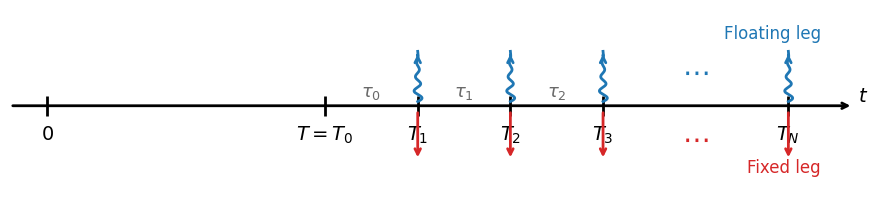

In [8]:
def plot_swaption_timeline():

    import numpy as np
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(11, 2.5))

    # Timeline coordinates
    x_t = 0.0
    timeline_x = [3.0, 4.0, 5.0, 6.0, 8.0]  # T0, T1, T2, T3, TN
    labels = [r"$T = T_0$", r"$T_1$", r"$T_2$", r"$T_3$", r"$T_N$"]

    # Draw main timeline with arrowhead at the end
    ax.annotate("", xy=(8.7, 0), xytext=(-0.4, 0),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.text(8.75, 0.12, r"$t$", ha="left", va="center", fontsize=14)

    # Mark today 0
    ax.vlines(x_t, -0.12, 0.12, color="black", linewidth=2)
    ax.text(x_t, -0.22, r"$0$", ha="center", va="top", fontsize=14)

    # Helper to draw a wiggly (floating-leg) arrow
    def draw_wiggly_arrow(ax, x, y0=0.05, y1=0.65, amp=0.05, waves=3.5, color="#1f77b4", lw=2):
        y = np.linspace(y0, y1, 180)
        phase = 2 * np.pi * waves * (y - y0) / (y1 - y0)
        taper = np.linspace(1.0, 0.0, y.size)
        x_wave = x + amp * np.sin(phase) * taper
        ax.plot(x_wave, y, color=color, linewidth=lw)
        ax.annotate(
            "",
            xy=(x, y1),
            xytext=(x, y1 - 0.08),
            arrowprops=dict(arrowstyle="->", color=color, lw=lw),
        )

    # Draw all timeline marks and labels
    for x, lab in zip(timeline_x, labels):
        ax.vlines(x, -0.12, 0.12, color="black", linewidth=2)
        ax.text(x, -0.22, lab, ha="center", va="top", fontsize=14)

    # Add accrual fractions between T0-T1, T1-T2, T2-T3
    tau_midpoints = [3.5, 4.5, 5.5]
    tau_labels = [r"$\tau_0$", r"$\tau_1$", r"$\tau_2$"]
    for x_tau, tau_lab in zip(tau_midpoints, tau_labels):
        ax.text(x_tau, 0.16, tau_lab, ha="center", va="center", fontsize=13, color="dimgray")

    # No payments at T0; payments start from T1
    payment_dates = timeline_x[1:]
    for x in payment_dates:
        draw_wiggly_arrow(ax, x)
        ax.annotate(
            "",
            xy=(x, -0.65),
            xytext=(x, -0.05),
            arrowprops=dict(arrowstyle="->", color="#d62728", lw=2),
        )

    # Show omitted intermediate payment dates between T3 and TN
    ax.text(7.0, 0.40, r"$\cdots$", color="#1f77b4", fontsize=20, ha="center", va="center")
    ax.text(7.0, -0.40, r"$\cdots$", color="#d62728", fontsize=20, ha="center", va="center")

    # Legend-like labels
    ax.text(8.35, 0.80, "Floating leg", color="#1f77b4", ha="right", fontsize=12)
    ax.text(8.35, -0.80, "Fixed leg", color="#d62728", ha="right", fontsize=12)

    ax.set_xlim(-0.4, 8.8)
    ax.set_ylim(-1.15, 1.15)
    ax.axis("off")
    # ax.set_title("Swaption Cashflow Timeline", fontsize=16, pad=10)

    plt.show()

plot_swaption_timeline()


\begin{align*}
\text{Time-$t$ Forward Swap NPV} &= \sum_{n=0}^{N-1}\tau_n P(t, T_{n+1})({\color{darkcyan}L(t, T_n, T_{n+1}) \color{red}- K})\\
&= \underbrace{\left(\sum_{n=0}^{N-1}\tau_n P(t, T_{n+1})\right)}_{A(t)}\left(\underbrace{\frac{\sum_{n=0}^{N-1}\tau_n P(t, T_{n+1})L(t, T_n, T_{n+1})}{\sum_{n=0}^{N-1}\tau_n P(t, T_{n+1})}}_{S(t)}- K\right)
\end{align*}

# Swaption Pricing (Cont.)

* Step 1: Change numeraire to the annuity
\begin{align*}
\text{Payer Swaption NPV } &= M_0E^M[M_T^{-1} {\color{lightgray}(A_T (S_T - K))^+}]\\
&= A_0E^A[A_T^{-1} {\color{lightgray}(A_T (S_T - K))^+}]\\
&= A_0E^A[(S_T - K)^+]
\end{align*}

* Step 2: Make assumption about $S_t$ dynamics **under the annuity measure**, say to follow SABR
\begin{align*}
\begin{cases}
dS_t = \alpha_tS_t^{\beta}\,dW_t^A\\
d\alpha_t = \nu \alpha_t\,dZ_t^A, \qquad \alpha_0 = \alpha\\
dW_t^AdZ_t^A = \rho dt
\end{cases}
\end{align*}
The assumption only gives us $E^A[(S_T - K)^+]$. We still need to get $A_0$ from today's curve

# CMS Spread Option Pricing

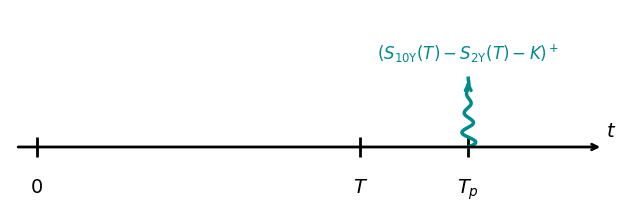

In [4]:
def plot_cms_timeline():
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(8, 2.5))

    # Time axis
    min_t, max_t = 0, 10
    
    # Draw main timeline with arrowhead at the end
    ax.annotate("", xy=(max_t + 0.5, 0), xytext=(-0.4, 0),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.text(max_t + 0.55, 0.12, r"$t$", ha="left", va="center", fontsize=14)

    # Markers for t=0, T, T_p
    T_val = 6
    T_p = 8
    
    ax.vlines(0, -0.07, 0.07, color="black", linewidth=2)
    ax.text(0, -0.22, "$0$", ha='center', va="top", fontsize=14)

    ax.vlines(T_val, -0.07, 0.07, color="black", linewidth=2)
    ax.text(T_val, -0.22, "$T$", ha='center', va="top", fontsize=14)

    ax.vlines(T_p, -0.07, 0.07, color="black", linewidth=2)
    ax.text(T_p, -0.22, "$T_p$", ha='center', va="top", fontsize=14)

    # Helper to draw a wiggly (floating-leg) arrow
    def draw_wiggly_arrow(ax, x, y0=0.0, y1=0.5, amp=0.15, waves=3.5, color="darkcyan", lw=2.5):
        import numpy as np
        y = np.linspace(y0, y1, 180)
        phase = 2 * np.pi * waves * (y - y0) / (y1 - y0)
        taper = np.linspace(1.0, 0.0, y.size)
        x_wave = x + amp * np.sin(phase) * taper
        ax.plot(x_wave, y, color=color, linewidth=lw)
        ax.annotate(
            "",
            xy=(x, y1),
            xytext=(x, y1 - 0.08),
            arrowprops=dict(arrowstyle="->", color=color, lw=lw),
        )

    # Drawing the cashflow
    cashflow_y = 0.5
    draw_wiggly_arrow(ax, T_p, y0=0, y1=cashflow_y, amp=0.15, waves=3.5, color="darkcyan", lw=2.5)
    
    ax.text(T_p, cashflow_y + 0.1, r"$(S_{\text{10Y}}(T) - S_{\text{2Y}}(T) - K)^+$", 
            ha='center', va='bottom', fontsize=12, color="darkcyan")
    
    ax.set_ylim(-0.4, 1)
    ax.set_xlim(-0.5, max_t + 1)
    ax.axis("off")

    plt.show()

plot_cms_timeline()

* Again all we need is a distribution $\color{red}f_{S_{\text{10Y}}, S_{\text{2Y}}}(s_1, s_2)$: 
\begin{align*}
\text{Cash Flow NPV} &= P(0, T_p) E^{T_p}[(S_{\text{10Y}}(T) - S_{\text{2Y}}(T) - K)^+]\\
&= P(0, T_p) \int\int(s_1 - s_2 - K)^+ {\color{red}f_{S_{\text{10Y}}, S_{\text{2Y}}}(s_1, s_2)}\,ds_1ds_2
\end{align*}


# Copula

* While $f_{S_{\text{10Y}}, S_{\text{2Y}}}(s_1, s_2)$ is unknown, its marginal distributions $f_{S_{\text{10Y}}}(s)$ and $f_{S_{\text{2Y}}}(s)$ are known (more on this later)
* When modeling a joint distribution, copula lets you specify the marginal distributions, while leaving parameters for correlation control
* Example with marginal distributions $\chi^2(3)$ and $\exp(1)$

In [ ]:
from scipy.stats import norm, multivariate_normal, chi2, expon
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_data_side_by_side(data1, data2, title1, title2):
    '''Plot two joint distributions side-by-side using nested subgridspec to emulate jointplots closely'''
    fig = plt.figure(figsize=(10, 3.5))
    outer_gs = fig.add_gridspec(1, 2, wspace=0.15)

    # --- Panel 1 ---
    gs1 = outer_gs[0].subgridspec(5, 5, wspace=0.3, hspace=0.3)
    ax1 = fig.add_subplot(gs1[1:5, 0:4])
    ax1_x = fig.add_subplot(gs1[0, 0:4], sharex=ax1)
    ax1_y = fig.add_subplot(gs1[1:5, 4], sharey=ax1)
    ax1_x.axis('off')
    ax1_y.axis('off')

    sns.kdeplot(x='x', y='y', data=data1, ax=ax1, fill=True, cmap='Blues')
    sns.kdeplot(x=data1['x'], ax=ax1_x, fill=True, color='tab:blue')
    sns.kdeplot(y=data1['y'], ax=ax1_y, fill=True, color='tab:blue')
    ax1_x.set_title(title1, pad=10)

    # --- Panel 2 ---
    gs2 = outer_gs[1].subgridspec(5, 5, wspace=0.3, hspace=0.3)
    ax2 = fig.add_subplot(gs2[1:5, 0:4], sharex=ax1, sharey=ax1)
    ax2_x = fig.add_subplot(gs2[0, 0:4], sharex=ax2)
    ax2_y = fig.add_subplot(gs2[1:5, 4], sharey=ax2)
    ax2_x.axis('off')
    ax2_y.axis('off')

    sns.kdeplot(x='x', y='y', data=data2, ax=ax2, fill=True, cmap='Reds')
    sns.kdeplot(x=data2['x'], ax=ax2_x, fill=True, color='tab:red')
    sns.kdeplot(y=data2['y'], ax=ax2_y, fill=True, color='tab:red')
    ax2_x.set_title(title2, pad=10)

    # Remove extra ticks
    for ax in [ax1, ax2]:
        ax.tick_params(top=False, right=False)

    # Set explicit limits with some margin
    ax1.set_xlim(-2, 18.0)
    ax1.set_ylim(-1, 6)

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        plt.tight_layout()
        
    plt.show()


rho1 = -0.8
rho2 = 0.8
n = 2000

np.random.seed(0)
# First dataset with rho = -0.8
data1 = DataFrame(multivariate_normal(cov=[[1.0, rho1], [rho1, 1.0]]).rvs(n), columns=['x', 'y'])
data1['x'] = chi2(df=3).ppf(norm.cdf(data1['x']))
data1['y'] = expon.ppf(norm.cdf(data1['y']))

# Second dataset with rho = +0.8
data2 = DataFrame(multivariate_normal(cov=[[1.0, rho2], [rho2, 1.0]]).rvs(n), columns=['x', 'y'])
data2['x'] = chi2(df=3).ppf(norm.cdf(data2['x']))
data2['y'] = expon.ppf(norm.cdf(data2['y']))

plot_data_side_by_side(
    data1, data2, 
    title1=rf'Gauss Copula $\rho = {rho1}$', 
    title2=rf'Gauss Copula $\rho = +{rho2}$'
)

# Gauss Copula

* Defined as
$$
C_\rho(u, v) = N_\rho(N^{-1}(u), N^{-1}(v))
$$
* $N(x)$ is the standard normal CDF, and $N^{-1}(u)$ its inverse function
* $N_\rho(x, y)$ is the bivariate normal CDF with covariance matrix
$$
\begin{pmatrix}
1 & \rho\\
\rho & 1
\end{pmatrix}
$$


* How to use: It can be shown that the CDF function 
$$
F_{X, Y}(x, y) = C_{\color{red}\rho}({\color{dodgerblue}F_X(x), F_Y(y)})
$$
has marginal CDFs $F_X(y)$ and $F_Y(y)$
* Copula lets you specify the <font color="dodgerblue">marginal distributions</font>, while leaving <font color="red">parameters for correlation control</font>

# Term Structure Models

* In a rates exotics desk, we manage the joint movement of the entire curve
* **The Challenge:** We need one single model to parameterize the first 4 moments of distribution not just at one point, but the entire yield curve

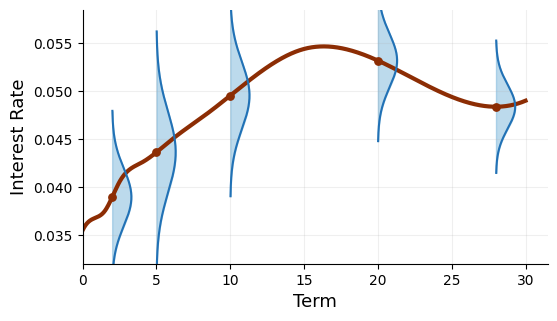

In [9]:
def plot_forward_curve_with_vols(figsize=(6, 3.3)):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import CubicSpline

    fwd_knots = np.array([0.0, 0.5, 1.5, 2.5, 4.0, 6.0, 8.5, 15.0, 25.0, 30.0])
    fwd_vals  = np.array([0.0355, 0.0365, 0.0375, 0.04055, 0.04255, 0.0449, 0.04773, 0.0544, 0.0494, 0.0490])
    cs = CubicSpline(fwd_knots, fwd_vals, bc_type='not-a-knot')
    maturity = np.linspace(0, 30, 1201)
    forward_curve = cs(maturity)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(maturity, forward_curve, color='#8c2d04', linewidth=3)

    pillars = np.array([2, 5, 10, 20, 28], dtype=float)
    pillar_forwards = cs(pillars)
    vols = np.array([0.0030, 0.0042, 0.0035, 0.0028, 0.0023])
    width_scale = 1.3

    for pillar, center, vol in zip(pillars, pillar_forwards, vols):
        move = np.linspace(-3 * vol, 3 * vol, 250)
        density = np.exp(-0.5 * (move / vol) ** 2)
        density /= density.max()
        x_right = pillar + width_scale * density
        ax.fill_betweenx(center + move, pillar, x_right, color='#6baed6', alpha=0.45)
        ax.plot(x_right, center + move, color='#2171b5', linewidth=1.5)
        ax.scatter([pillar], [center], color='#8c2d04', s=28, zorder=3)

    ax.set_xlim(0, 31.5)
    ax.set_ylim(0.032, 0.0585)
    ax.set_xlabel('Term', fontsize=13)
    ax.set_ylabel('Interest Rate', fontsize=13)
    ax.grid(alpha=0.2)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.show()

plot_forward_curve_with_vols()

# Heath–Jarrow–Morton (HJM) Framework

* Under the risk-neutral probability, **once forward rate vol is determined, so is its drift** 
* $f(t, T)$: Instantaneous forward rate for the reference period $[T, T+\epsilon]$ observed at $t$
* $\sigma(t, T)$: Forward rate vol
* ${\color{lightgray}\Sigma(t, T) = \int_t^T\sigma(t, u)\,du: \text{zero coupon bond vol}}$
$$
df(t, T) = {\color{lightgray} \sigma(t, T)\Sigma(t, T)\,dt} + \sigma(t, T)\,d\widetilde W(t), \qquad t<T
$$

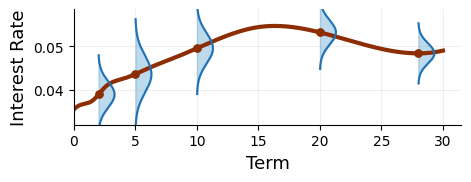

In [10]:
plot_forward_curve_with_vols(figsize=(5, 1.5))


* Think of a fixed $T$, say 10Y
$$
df_{\text{10Y}}(t) = {\color{lightgray} \sigma_{\text{10Y}}(t)\Sigma_{\text{10Y}}(t)\,dt} + \sigma_{\text{10Y}}(t)\,d\widetilde W(t), \qquad t<\text{10Y}
$$
    

<div class="fragment">
    <ul style="text-align: left; margin-bottom: 0;">
        <li>Think of a fixed $T$, say 10Y</li>
    </ul>
    <div style="text-align: center; width: 100%;">
        $$df_{\text{10Y}}(t) = {\color{lightgray} \sigma_{\text{10Y}}(t)\Sigma_{\text{10Y}}(t)\,dt} + \sigma_{\text{10Y}}(t)\,d\widetilde W(t), \qquad t<\text{10Y}$$
    </div>
</div>

# HJM Is Not Optional

* **To guarantee no arbitrage**, any model for the instantaneous forward rate must have the drift term in the form as specified in the HJM framework

* But if you don't model instantaneous forward rate, then HJM is irrelevant
    * An example is the LIBOR Market Model

* We only have to specify a $\sigma(t, T)$ to obtain a concrete HJM model for pricing and hedging
* So how can we specify a $\sigma(t, T)$? Some properties: 
    * Separable
    * Time stationary
    * Deterministic

# Separable Vol

* A special class of HJM models where the volatility function is in the form 
$$
\sigma(t, T) = g(t)h(T)
$$ 
* Why does it matter? 

* It can be shown that **in an HJM model with separable vol, the forward rate is Markovian**
* **Markov Process:** A random process's future state only depends on its current state, not the past
    * Markovian example: 
    $$
    E[X_{t+1}|\mathcal F_t] = E[X_{t+1}|X_t]
    $$
    * Non-Markovian example: 
    $$
    E[X_{t+1}|\mathcal F_t] = E[X_{t+1}~|~X_t, X_{t-1}, X_{t-2}]
    $$

* Models with non-Markovian rates are path-dependent: the hedge ratio depends on the entire history, **making dynamic hedging practically infeasible** and pricing computationally explosive; the rates are also predictable from past observations, opening the door to statistical arbitrage

# Time Stationary Vol

* If the forward rate vol is a function of $\tau = (T-t)$, we say it's time stationary
* Why does it matter? 


* Today's 10Y forward rate vol is $\sigma(0, 10)$
* 1M from now, the same model gives the 10Y forward rate vol $\sigma(\frac{1}{12}, 10 + \frac{1}{12})$
* When $\sigma(t, T)$ is time stationary, they are the same

* $\tau = (T-t)$ is the term in a term structure model
* Time stationary vol means the vol stays constant for the same term when time $t$ moves forward

* **Without further information, time stationary vol is a good assumption**

# Gaussian HJM Model

* Assume that $\sigma(t, T)$ is deterministic, giving normally distributed forward rates
$$
f(t, T) = {\color{lightgray} f(0, T) + \int_0^t\sigma(s, T)\Sigma(s, T)\,ds} + \int_0^t\sigma(s, T)\,d\widetilde W(s), \qquad t<T
$$
* Examples: 
    * Hull-White One Factor (HW1F)
    $$\sigma(t, T) = \sigma e^{-k(T-t)} = \sigma e^{-k\tau}$$
    * Ho-Lee: Constant forward rate vol, special case of HW1F with $k\downarrow 0$
    $$\sigma(t, T) = \sigma$$

* It can be shown that **the only HJM model with separable, time stationary and deterministic vol is the Hull-White model (HWNF)**

# Curve Movement in the Ho-Lee Model

* Given $\sigma(t, T) = \sigma$, at time $t=0$, the forward rate evolves as
\begin{align*}
df(t, T) &= \sigma^2T\,dt + \sigma \,d\widetilde W(t) \\
&\approx {\color{darkcyan}\sigma^2\tau\Delta t} + {\color{red}\sigma (\widetilde W(\Delta t))}
\end{align*}
* $df(t, T)$ (as a function of $T$): Tomorrow's forward curve movement
* ${\color{darkcyan}\sigma^2\tau\Delta t}$: An upward-sloping straight line, **deterministic curve steepening**
* ${\color{red}\sigma (\widetilde W(\Delta t))}$: **Perfect parallel shift** with random magnitude 


* **The Ho-Lee model implies that the curve is always steepening**, albeit by a very small amount

# HW1F 

With $\sigma(t, T) = \sigma e^{-\kappa \tau}$, the forward rate evolves as
\begin{align*}
df(t, T) &= {\color{lightgray}\sigma(t, T)\Sigma(t, T)\,dt} + \sigma(t, T)\,d\widetilde W(t)\\
&= {\color{lightgray}\left(y(t) - kx(t) + \frac{1-e^{-k\tau}}{k} (\sigma^2 - 2ky(t))\right)\,dt} + \sigma e^{-k\tau}\,d\widetilde W(t), 
\end{align*}
<font color="lightgray">where </font>${\color{lightgray}x(0) = y(0) = 0,}$
\begin{align*}
{\color{lightgray}
\begin{cases}
dx(t) = (y(t) - \kappa x(t))dt + \sigma d\widetilde W(t)\\
dy(t) = (\sigma^2 - 2\kappa y(t)) dt
\end{cases}. 
}
\end{align*}
<font color="lightgray">The ODE of </font>${\color{lightgray}y(t)}$<font color="lightgray"> can be solved explicitly to obtain</font>
$$
{\color{lightgray}y(t) = \frac{\sigma^2\left(1-e^{-2\kappa t}\right)}{2\kappa}, }
$$
and the state variable $x(t)$ is normally distributed. 


# Curve Movement in HW1F

At $t=0$, tomorrow's curve movement is
\begin{align*}
df(t, T) \approx \underbrace{\frac{\sigma^2(1-e^{-k\tau})}{k} \Delta t}_{\color{darkcyan}(1)} + \underbrace{\sigma e^{-k\tau} \widetilde W(\Delta t)}_{\color{red}(2)}
\end{align*}
* <font color="darkcyan">(1): </font>Deterministic curve steepening
* <font color="red">(2): </font>Curve movement with random magnitude ($\widetilde W(\Delta t) = \sqrt{\Delta t}Z$ below)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import warnings
warnings.filterwarnings('ignore')

tau = np.linspace(0, 20, 1000)

@interact(sigma=(0.01, 0.5, 0.01), k=(0.01, 1, 0.01), Z=(-3, 3, 0.1))
def plot_curve_movement(sigma=0.2, k=0.4, Z=-1):
    s = sigma
    dt = 1/365
    
    drift = (s**2) * (1 - np.exp(-k * tau)) * dt / k
    diffusion = s * np.sqrt(dt) * np.exp(-k * tau) * Z
    total_movement = drift + diffusion
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3.5))
    
    ax1.plot(tau, drift, linewidth=2, color='darkcyan')
    ax1.set_title('(1) Deterministic Steepening', color='darkcyan')
    ax1.set_xlim(0, 20)
    ax1.set_ylim(-0.1, 0.1)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel(r'$\tau$')
    ax1.set_ylabel('Curve Movement')
    
    ax2.plot(tau, diffusion, linewidth=2, color='red')
    ax2.set_title('(2) Random Movement', color='red')
    ax2.set_xlim(0, 20)
    ax2.set_ylim(-0.1, 0.1)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel(r'$\tau$')
    
    ax3.plot(tau, total_movement, linewidth=2, color='blue')
    ax3.set_title('Total Curve Movement', color='blue')
    ax3.set_xlim(0, 20)
    ax3.set_ylim(-0.1, 0.1)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlabel(r'$\tau$')
    
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.2, description='sigma', max=0.5, min=0.01, step=0.01), FloatSlider(v…

# HW2F and PCA

* At $t=0$, tomorrow's curve movement is
\begin{align*}
{\small
df(t, T) \approx (\text{Deterministic Term}) + \underbrace{\left(\sigma_1 e^{-k_1\tau} + \rho\sigma_2e^{-k_2\tau}\right) \widetilde W_1(\Delta t)}_{\color{red}(1)} + \underbrace{\left(\sigma_2\sqrt{1-\rho^2} e^{-k_2\tau}\right) \widetilde W_2(\Delta t)}_{\color{dodgerblue}(2)}, 
}
\end{align*}
where $\widetilde W_1(\Delta t) \perp\!\!\!\perp \widetilde W_2(\Delta t)$. 
* ${\color{red}(1)}$: Curve movement contributed by PC1
* ${\color{dodgerblue}(2)}$: Curve movement contributed by PC2


# Bond Reconstruction Formula

* In the Hull-White model, the zero coupon bond (ZCB) price $P(t, T)$ is known in closed form in terms of the state variable(s)
$$
P(t, T) = P(t, T, x_t) {\color{lightgray} = \frac{P(0, T)}{P(0, t)} \exp\left(-G(t, T)x_t - \frac{1}{2}G^2(t, T)y_t\right), }
$$
<font color="lightgray">where </font>
$$
{\color{lightgray} G(t, T) = \frac{1-e^{k(T-t)}}{k}, \qquad y_t = \frac{\sigma^2(1-e^{2kt})}{2k}}
$$
* Why is this useful? 


* Many important quantities can be written in terms of ZCBs, including:
    * Forward rate $L(t, T, T+\tau) = (P(t, T)/P(t, T+\tau) - 1)/\tau$
    * Swap rate, as it's a weighted average of forward rates. We denote this by $S(t, x_t)$
    * Annuity, as it's a basket of ZCBs. We denote this by $A(t, x_t)$

# Problem With HW

* Despite all the benefits of the Hull-White model, it doesn't give us control over the 3rd and the 4th moments (IV skews and convexity)
* $f(t, T)$ is normally distributed
* The swap rate $S(t, x_t)$ is not, but there is no parameter for IV skew control

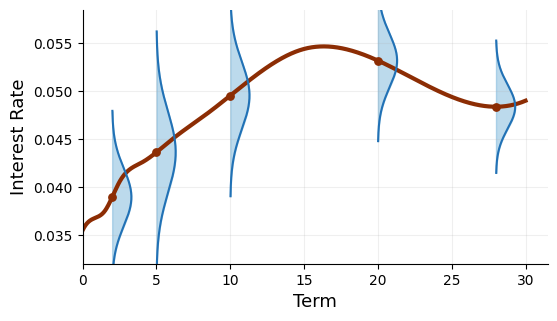

In [12]:
plot_forward_curve_with_vols()

# From HW to Cheyette

\begin{align*}
\begin{cases}
dx_t = (y_t - \kappa x_t)dt + {\color{red}\sigma} d\widetilde W_t\\
dy_t = ({\color{red}\sigma}^2 - 2\kappa y_t) dt
\end{cases}
\end{align*}
* HW: Constant $\sigma$
* Cheyette: $\sigma(t, x_t, y_t) = a_0 + a_1 x_t$
* Similar to the displaced lognormal model, there is now a **skew parameter $a_1$**


* Since $\sigma$ is random now, so is $y_t$


* Bond reconstruction formula still holds but with random $y_t$: 
$$
P(t, T) = P(t, T, x_t, y_t) {\color{lightgray} = \frac{P(0, T)}{P(0, t)} \exp\left(-G(t, T)x_t - \frac{1}{2}G^2(t, T)y_t\right), }
$$
<font color="lightgray">where </font>
$$
{\color{lightgray} G(t, T) = \frac{1-e^{k(T-t)}}{k}}
$$

# Cheyette Model With Stochastic Volatility

* Extension to SV gives us a **vol of vol parameter ${\color{dodgerblue}\nu}$ to control the convexity of IV**
\begin{align*}
\begin{cases}
\color{lightgray}dx_t = (y_t - \kappa x_t)dt + {\color{black}\sqrt{\alpha_t}}\sigma(t, x_t, y_t) d\widetilde W_t\\
\color{lightgray}dy_t = ({\color{black}\alpha_t}\sigma^2(t, x_t, y_t) - 2\kappa y_t) dt\\
d\alpha_t = k(\theta - \alpha_t)\,dt + {\color{dodgerblue}\nu}\sqrt{\alpha_t}\,dZ_t
\end{cases}
\end{align*}

# Appendix: Swaption Pricing in Cheyette

* Swap rate is now $S(t, x_t, y_t)$, where $S(\cdot, \cdot, \cdot)$ is a lengthy formula but in closed form
* To find swaption NPV approximation, we find swap rate dynamics approximation: 
\begin{align*}
dS_t &= \frac{\partial S}{\partial x}(t, x_t, y_t)\,dx_t \\
&= \frac{\partial S}{\partial x}(t, x_t, y_t)\sigma(t, x_t, y_t)\,dW^A_t
\end{align*}

* Replace $y_t$ by $\bar y_t$, the deterministic function in HW: 
$$
dS_t \approx \frac{\partial S}{\partial x}(t, x_t, \bar y_t)\sigma(t, x_t, \bar y_t)\,dW^A_t
$$
* The right hand side is in terms of $x_t$, not $S_t$, which is undesired

$$
dS_t \approx \frac{\partial S}{\partial x}(t, x_t, \bar y_t)\sigma(t, x_t, \bar y_t)\,dW^A_t
$$


* Expand $S(t, x, y)$ in $x$ to the first order and find the inverse function as an approximation of $x(t, S)$. Denote the inverse function by $\xi(t, s)$. Next write
$$
dS_t \approx \underbrace{\frac{\partial S}{\partial x}(t, \xi(t, S_t), \bar y_t)\sigma(t, \xi(t, S_t), \bar y_t)}_{\text{RHS vol}}\,dW^A_t
$$

* Find first order approximation $\text{RHS vol} \approx a_0(t) + a_1(t) S_t$. Now we have a swap rate dynamics approximation which is displaced lognormal and can be used in pricing: 
$$
dS_t = (a_0(t) + a_1(t) S_t)\,dW^A_t
$$

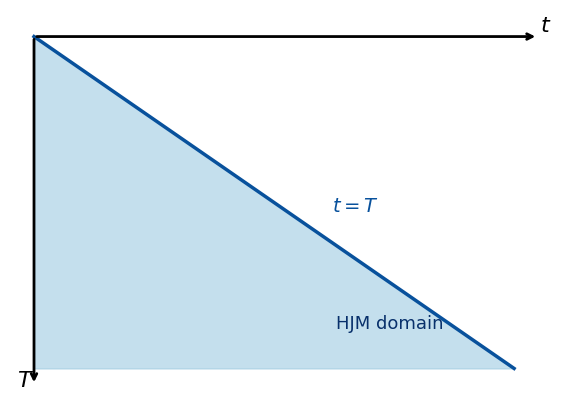

In [14]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Use y = -T so the T-axis points downward on the page.
t_max = 10
T_max = 10

t = np.linspace(0, t_max, 400)
y_line = -t

# Shade the region below the line t = T in the fourth quadrant.
ax.fill_between(t, y_line, -T_max, color="#9ecae1", alpha=0.6)
ax.plot(t, y_line, color="#08519c", linewidth=2.5)

# Clean frame and draw custom axes.
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(-0.5, t_max + 0.8)
ax.set_ylim(-T_max - 0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])

ax.annotate("", xy=(t_max + 0.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))
ax.annotate("", xy=(0, -T_max - 0.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))

ax.text(t_max + 0.55, 0.15, r"$t$", fontsize=16)
ax.text(-0.35, -T_max - 0.55, r"$T$", fontsize=16)
ax.text(6.2, -5.3, r"$t = T$", color="#08519c", fontsize=14)
ax.text(6.3, -8.8, "HJM domain", color="#08306b", fontsize=13)

plt.show()